# QAOA with BlueQubit

In this tutorial, we are solving the MIS (Maximal Independent Set) problem using the QAOA method where the
energy calculation is done using BlueQubit's Pauli-path
simulator (PPS). We found that when the number of qubits
is high enough (25), with deep enough p_layers, optimization with PPS is ~10x
faster than the CPU statevector simulator. And at 30 qubits,
the PPS is faster than even the GPU statevector simulator.

In [1]:
import os
import warnings

os.environ["BLUEQUBIT_LOG_LEVEL"] = "ERROR"
warnings.filterwarnings("ignore", category=UserWarning)

In [2]:
import time
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
from scipy.optimize import minimize
from qiskit import QuantumCircuit
from qiskit.circuit import ParameterVector
from qiskit.quantum_info import SparsePauliOp

import bluequbit

bq = bluequbit.init()

## Problem Statement

Maximum Independent Set (MIS): Find the largest subset
$S$ of vertices of a graph where no two vertices are connected by an
edge.

Binary encoding: $x_i = 1$ if node $i$ is in MIS, $0$ otherwise
The QUBO formulation maximizes the set size while
penalizing invalid solutions:
- Objective: $\max \sum_i x_i - A \sum_{(i,j)\in E} x_i x_j$
  
- $\sum_i x_i$ rewards including vertices (maximizes set size)

  
- $A \sum_{(i,j)\in E} x_i x_j$ penalizes adjacent vertices both
being selected ($A > 0$)

When $A$ is large enough, the penalty ensures no adjacent
vertices are chosen, making any solution a valid
independent set.

QUBO → Ising transformation:
  - Variable mapping: $x_i = (1 + z_i)/2$ converts binary
    variables $(0,1)$ to spin variables $(-1,+1)$
  - Objective transformation: The QUBO $\max \sum_i x_i - A \sum_{(i,j)\in E} x_i x_j$
    becomes the Ising Hamiltonian $C = \sum_i h_i z_i + \sum_{(i,j)} J_{ij} z_i z_j$

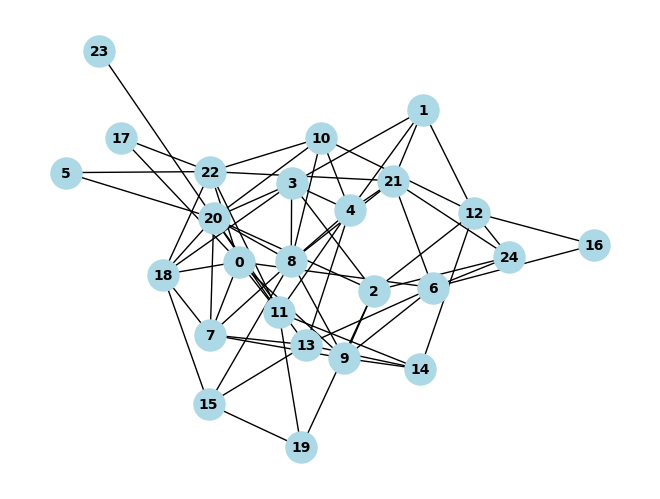

In [3]:
# 1. Prepare a random Erdős–Rényi graph
N = 25  # Number of nodes/qubits
seed = 42
G = nx.fast_gnp_random_graph(N, 0.2, seed=seed)
pos = nx.spring_layout(G, seed=seed)
nx.draw(
    G,
    pos,
    node_color="lightblue",
    with_labels=True,
    node_size=500,
    font_size=10,
    font_weight="bold",
)

In [4]:
# 2. MIS → Ising
A = 7.0  # penalty parameter

terms = []
# single-qubit Z terms: hᵢ = -1/2 + (A/4)·deg(i)
for v in G.nodes():
    coeff = 0.5 - (A / 4) * G.degree(v)
    terms.append((coeff, (v,)))

# ZZ coupling terms for edges: Jᵢⱼ = A/4
for u, v in G.edges():
    coeff = A / 4
    terms.append((coeff, (u, v)))


def cost_op(terms):
    def pauli(indices):
        label = ["I"] * N
        for i in indices:
            label[N - 1 - i] = "Z"
        return "".join(label)

    labels, coeffs = [], []
    for coeff, qubits in terms:
        labels.append(pauli(qubits))
        coeffs.append(coeff)
    return SparsePauliOp(labels, coeffs)

## The Ansatz

QAOA alternates between cost unitary $U_C(\gamma)$ and mixer unitary $U_M(\beta)$.

Cost unitary: $U_C = \exp(-i\gamma C)$ where $C$ is the Ising Hamiltonian.

Mixer unitary: $U_M = \exp(-i\beta\sum_i X_i)$ applies transverse field to all qubits.

In [5]:
# 3. QAOA ansatz factory
def qaoa_ansatz(p, terms):
    γ = ParameterVector("γ", p)  # cost parameters
    β = ParameterVector("β", p)  # mixer parameters
    qc = QuantumCircuit(N)
    qc.h(range(N))  # initial superposition |+⟩⊗N
    for layer in range(p):
        # cost-unitary: exp(-iγC) decomposed into Pauli rotations
        for coeff, qubits in terms:
            if len(qubits) == 2:  # ZZ term: exp(-iγJᵢⱼZᵢZⱼ)
                i, j = qubits
                qc.rzz(2 * coeff * γ[layer], i, j)
            elif len(qubits) == 1:  # Z term: exp(-iγhᵢZᵢ)
                i = qubits[0]
                qc.rz(2 * coeff * γ[layer], i)
        # mixer: exp(-iβΣᵢXᵢ) = ∏ᵢ exp(-iβXᵢ)
        qc.rx(2 * β[layer], range(N))
    return qc, γ, β

In [6]:
# 4. Build once
C_op = cost_op(terms)
p_layers = 3
ansatz, γ, β = qaoa_ansatz(p_layers, terms)


def get_energy(params):
    b = {γ[i]: params[i] for i in range(p_layers)}
    b.update({β[i]: params[p_layers + i] for i in range(p_layers)})
    qc = ansatz.assign_parameters(b, inplace=False)
    device = "pauli-path"
    # device = "mps.cpu"
    # device = "cpu"
    result = bq.run(
        qc,
        device=device,
        pauli_sum=[(i[0], i[1].real) for i in C_op.to_list()],
        options=dict(pauli_path_truncation_threshold=0.1),
    )
    elapsed = result.run_time_ms
    out = result.expectation_value
    print("Energy", out, "elapsed 1 step (milliseconds)", elapsed)
    return out

## Run experiment

Run classical optimization loop: minimize $\langle\psi(\gamma,\beta)|C|\psi(\gamma,\beta)\rangle$ over parameters. Then sample from optimized quantum state to extract bit-strings.

In [7]:
# 5. Run several restarts and pick the best result
best_size = 0
best_bitstr = ""
best_ind_set = []
all_energy_histories = []
current_energy_history = []


def get_energy_with_tracking(params):
    energy = get_energy(params)
    current_energy_history.append(energy)
    return energy


N_retries = 5

start_time = time.time()
for attempt in range(1, N_retries + 1):
    current_energy_history = []
    seed = 101 + attempt
    rng = np.random.default_rng(seed)
    x0 = 0.1 * rng.standard_normal(2 * p_layers)

    # Classical optimization of QAOA parameters
    res = minimize(
        get_energy_with_tracking,
        x0,
        method="COBYLA",
        options={"maxiter": 50, "rhobeg": 0.5},
    )
    # sample once at the optimum to extract candidate solution
    bopt = {γ[i]: res.x[i] for i in range(p_layers)}
    bopt.update({β[i]: res.x[p_layers + i] for i in range(p_layers)})
    qc = ansatz.assign_parameters(bopt, inplace=False)
    qc.measure_all()
    print("Sampling the optimized circuit using the statevector simulator...")
    result = bq.run(qc, "cpu", shots=None)
    probs = result.get_counts()
    bitstr = max(probs, key=probs.get)  # most probable bit-string
    ind_set = [i for i, b in enumerate(bitstr[::-1]) if b == "1"]  # decode MIS

    if len(ind_set) > best_size:
        best_size = len(ind_set)
        best_bitstr = bitstr
        best_ind_set = ind_set

    all_energy_histories.append(current_energy_history.copy())
    print(f"∘ restart {attempt:2d}: got {ind_set}  (size {len(ind_set)})")

end_time = time.time()


print(f"\nBest result after {N_retries} restarts:")
print("bit-string :", best_bitstr)
print("MIS       :", best_ind_set, f"(size = {best_size})")
print(f"Time taken: {end_time - start_time:.2f} seconds")

Energy -36.106914165664264 elapsed 1 step (milliseconds) 0
Energy -29.43214219810209 elapsed 1 step (milliseconds) 0
Energy -68.26720609855359 elapsed 1 step (milliseconds) 1000
Energy -35.613836389338985 elapsed 1 step (milliseconds) 2000
Energy 113.39928262444172 elapsed 1 step (milliseconds) 0
Energy -50.34950772133371 elapsed 1 step (milliseconds) 1000
Energy -155.9276778790997 elapsed 1 step (milliseconds) 1000
Energy -74.8821972962062 elapsed 1 step (milliseconds) 1000
Energy -136.75877214153525 elapsed 1 step (milliseconds) 0
Energy 42.494460529959944 elapsed 1 step (milliseconds) 0
Energy 1.543168394828186 elapsed 1 step (milliseconds) 1000
Energy -115.8350477308388 elapsed 1 step (milliseconds) 1000
Energy -5.217837142948556 elapsed 1 step (milliseconds) 1000
Energy -74.19290141400437 elapsed 1 step (milliseconds) 1000
Energy -148.4124139157569 elapsed 1 step (milliseconds) 0
Energy -152.62877371967815 elapsed 1 step (milliseconds) 1000
Energy 76.606777753287 elapsed 1 step (m

## Analyze Experiment Data

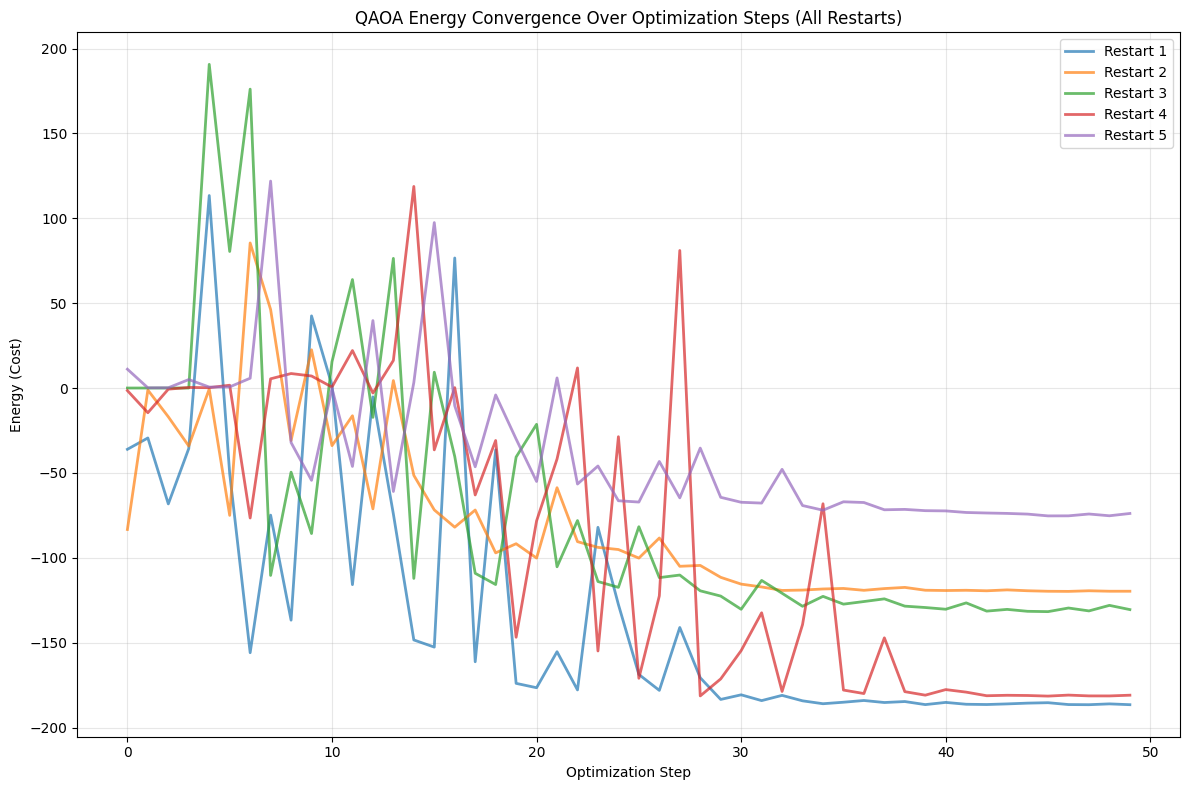

In [8]:
# Plot energy convergence over optimization steps
plt.figure(figsize=(12, 8))
for i, history in enumerate(all_energy_histories):
    plt.plot(history, linewidth=2, alpha=0.7, label=f"Restart {i + 1}")
plt.xlabel("Optimization Step")
plt.ylabel("Energy (Cost)")
plt.title("QAOA Energy Convergence Over Optimization Steps (All Restarts)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

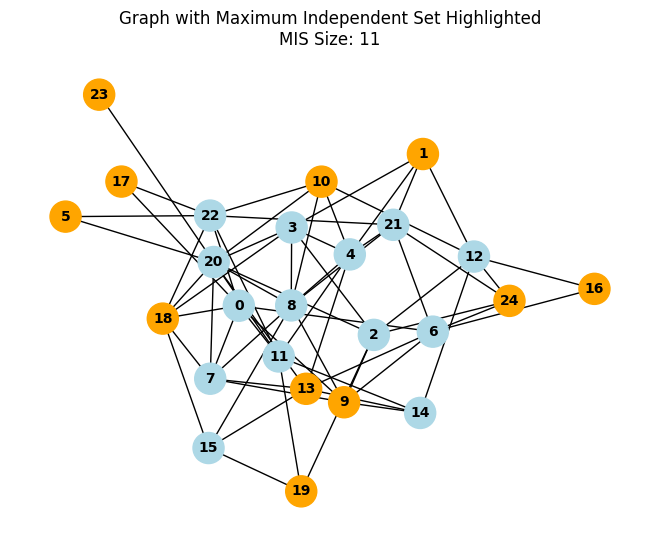

In [9]:
# Draw the graph with MIS nodes highlighted
plt.figure()
node_colors = ["orange" if node in best_ind_set else "lightblue" for node in G.nodes()]
nx.draw(
    G,
    pos,  # reuse from previous nx.draw
    node_color=node_colors,
    with_labels=True,
    node_size=500,
    font_size=10,
    font_weight="bold",
)
plt.title(f"Graph with Maximum Independent Set Highlighted\nMIS Size: {best_size}")
plt.show()

## Check Correctness of Solution

In [10]:
# Checking whether the solution is a true MIS
def check_mis(G, bitstring):

    # Needs to reverse because of Qiskit endian
    node_order = reversed(list(G.nodes()))

    chosen = [n for n, b in zip(node_order, bitstring) if b == "1"]

    independent = G.subgraph(chosen).number_of_edges() == 0
    maximal = all(any(G.has_edge(v, u) for u in chosen) for v in set(G) - set(chosen))
    best_classical_mis_size = 0
    for i in range(N_retries):
        mis = nx.algorithms.mis.maximal_independent_set(G, seed=i)
        best_classical_mis_size = max(best_classical_mis_size, len(mis))

    return {
        "independent": independent,
        "maximal": maximal,
        "better_than_classical": len(chosen) >= best_classical_mis_size,
        "classical_MIS_size": best_classical_mis_size,
    }


print(check_mis(G, best_bitstr))

{'independent': True, 'maximal': True, 'better_than_classical': True, 'classical_MIS_size': 9}


⚠️ The optimal bitstring returned by the above method may not always represent a maximal independent set (MIS), or even a valid independent set. Tuning the penalty term $A$, p_layers, and N_retries can improve the likelihood of obtaining a correct or higher-quality solution.

➕ To learn more about Pauli-Path Simulators, we refer to our [tutorial on Pauli-Path Simulations](https://app.bluequbit.io/tutorial/2tmSchlAGgRBTKxC "PPS tutorial")